In [1]:
import glob, json, os
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "outputs"
csv_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "phase1_*.csv")))
print(f"Found {len(csv_files)} runs:\n")

runs = {}
for csv_path in csv_files:
    tag = os.path.basename(csv_path).replace("phase1_", "").replace(".csv", "")
    meta_path = csv_path.replace(".csv", "_metadata.json")
    df = pd.read_csv(csv_path)
    runs[tag] = df

    # Print true value magnitudes from metadata
    if os.path.exists(meta_path):
        meta = json.load(open(meta_path))
        avg_mag = meta.get("avg_magnitude_true_value", {})
        lam = meta.get("LAMBDA", "?")
        mlp = meta.get("MLP_LAYERS", "?")
        print(f"{tag}")
        print(f"  lambda={lam}, arch={mlp}")
        for k, v in avg_mag.items():
            print(f"  {k} avg|V| = {v:.4f}")
        print(f"  final pct_err = {df['pct_err_total'].iloc[-1]:.2f}%")
        print()

Found 8 runs:

lam0.0_mlp16161616
  lambda=0.0, arch=[16, 16, 16, 16]
  agent_0 avg|V| = 1.2810
  agent_1 avg|V| = 1.0764
  agent_2 avg|V| = 1.0972
  agent_3 avg|V| = 1.2371
  final pct_err = 24.91%

lam0.4_mlp128128
  lambda=0.4, arch=[128, 128]
  agent_0 avg|V| = 1.2810
  agent_1 avg|V| = 1.0764
  agent_2 avg|V| = 1.0972
  agent_3 avg|V| = 1.2371
  final pct_err = 22.89%

lam0.4_mlp16161616
  lambda=0.4, arch=[16, 16, 16, 16]
  agent_0 avg|V| = 1.2810
  agent_1 avg|V| = 1.0764
  agent_2 avg|V| = 1.0972
  agent_3 avg|V| = 1.2371
  final pct_err = 25.26%

lam0.4_mlp161616161616
  lambda=0.4, arch=[16, 16, 16, 16, 16, 16]
  agent_0 avg|V| = 1.2810
  agent_1 avg|V| = 1.0764
  agent_2 avg|V| = 1.0972
  agent_3 avg|V| = 1.2371
  final pct_err = 25.44%

lam0.4_mlp32
  lambda=0.4, arch=[32]
  agent_0 avg|V| = 1.2810
  agent_1 avg|V| = 1.0764
  agent_2 avg|V| = 1.0972
  agent_3 avg|V| = 1.2371
  final pct_err = 23.13%

lam0.4_mlp6464
  lambda=0.4, arch=[64, 64]
  agent_0 avg|V| = 1.2810
  age

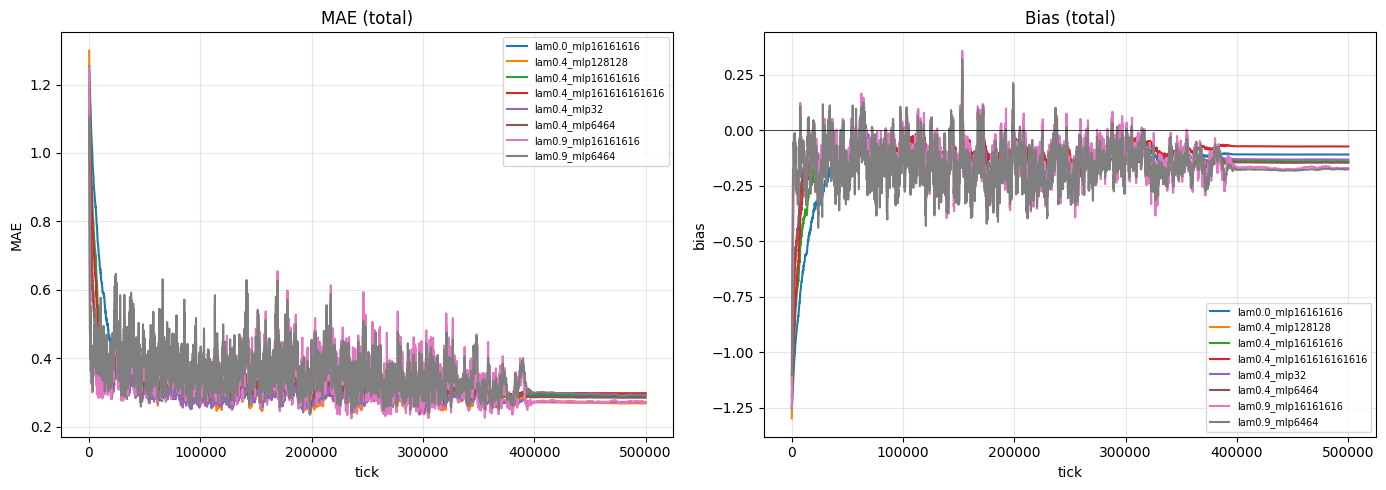

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tag, df in runs.items():
    axes[0].plot(df['tick'], df['mae_total'], label=tag)
    axes[1].plot(df['tick'], df['bias_total'], label=tag)

axes[0].set_title('MAE (total)')
axes[0].set_xlabel('tick')
axes[0].set_ylabel('MAE')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Bias (total)')
axes[1].set_xlabel('tick')
axes[1].set_ylabel('bias')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()